In [1]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_text_classification.csv to customer_support_text_classification.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("customer_support_text_classification.csv")


In [4]:
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [5]:
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [6]:
print("Number of records:", len(df))

Number of records: 1500


In [9]:
print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [10]:
print("Number of records:", len(df))

Number of records: 1500


In [11]:
print(df['sentiment_label'].unique())

['neutral' 'positive' 'negative']


In [12]:
print(df['sentiment_label'].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [13]:
df['text_length'] = df['customer_message'].apply(len)

print("Average text length:", df['text_length'].mean())

Average text length: 72.75666666666666


In [14]:
print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


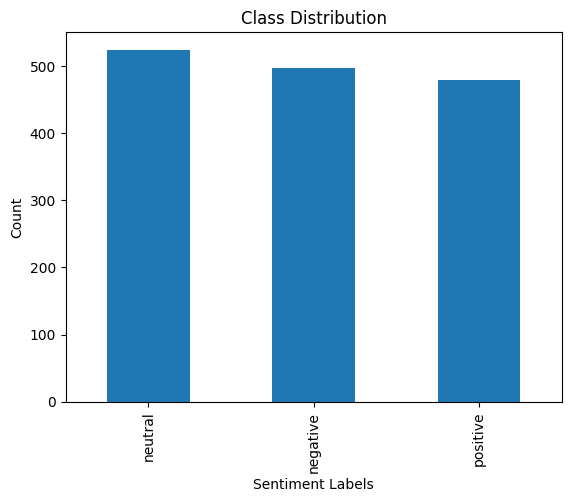

In [15]:
import matplotlib.pyplot as plt

df['sentiment_label'].value_counts().plot(kind='bar')

plt.title("Class Distribution")

plt.xlabel("Sentiment Labels")

plt.ylabel("Count")

plt.show()

task 2

In [16]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
df['cleaned_text'] = df['customer_message'].str.lower()

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,i need information about the payment process. ...
1,I need information about the payment process.,i need information about the payment process.
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient. i ...
3,My refund is still pending and this experience...,my refund is still pending and this experience...
4,Please tell me how to update my account details.,please tell me how to update my account details.


In [18]:
df['cleaned_text'] = df['cleaned_text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

df['cleaned_text'].head()

,cleaned_text
0,i need information about the payment process m...
1,i need information about the payment process
2,the refund process was fast and convenient i a...
3,my refund is still pending and this experience...
4,please tell me how to update my account details


In [21]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
df['tokens'] = df['cleaned_text'].apply(word_tokenize)

df['tokens'].head()

,tokens
0,"[i, need, information, about, the, payment, pr..."
1,"[i, need, information, about, the, payment, pr..."
2,"[the, refund, process, was, fast, and, conveni..."
3,"[my, refund, is, still, pending, and, this, ex..."
4,"[please, tell, me, how, to, update, my, accoun..."


In [23]:
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df['tokens'].head()

,tokens
0,"[need, information, payment, process, ticket, ..."
1,"[need, information, payment, process]"
2,"[refund, process, fast, convenient, appreciate..."
3,"[refund, still, pending, experience, frustrati..."
4,"[please, tell, update, account, details]"


In [24]:
df['processed_text'] = df['tokens'].apply(
    lambda words: ' '.join(words)
)

df['processed_text'].head()

,processed_text
0,need information payment process ticket number...
1,need information payment process
2,refund process fast convenient appreciate quic...
3,refund still pending experience frustrating ti...
4,please tell update account details


In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [26]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['processed_text'])

sequences = tokenizer.texts_to_sequences(df['processed_text'])

In [27]:
max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(padded_sequences.shape)

(1500, 50)


task 3

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['processed_text'])

print("TF-IDF Shape:", X_tfidf.shape)

TF-IDF Shape: (1500, 146)


In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [31]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['processed_text'])

In [32]:
sequences = tokenizer.texts_to_sequences(df['processed_text'])

print(sequences[:3])

[[14, 104, 64, 18, 1, 2, 3, 4, 5, 6], [14, 104, 64, 18], [13, 18, 37, 38, 15, 16, 9]]


In [33]:
max_length = 50

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(padded_sequences.shape)

(1500, 50)


## Why Text Must Be Converted Into Vectors

Machine learning models cannot directly understand raw text data.

Text must be converted into numerical vectors so that the model can process patterns, relationships, and word importance mathematically.

Techniques such as TF-IDF and tokenizer-based sequences transform text into numerical representations that can be used for training deep learning and machine learning models.

In [34]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [35]:
X = X_tfidf

y = df['sentiment_label']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [37]:
model = LogisticRegression()

In [38]:
model.fit(X_train, y_train)

LogisticRegression()

In [39]:
y_pred = model.predict(X_test)

In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Baseline Model

A Logistic Regression model was built using TF-IDF vectorized text features.

The dataset was split into training and testing sets.  
The model was trained on the training data and evaluated using accuracy score and classification report.

Logistic Regression was selected as a simple and effective baseline model for text classification tasks.

In [ ]:
task 5

In [42]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [43]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['sentiment_label'])

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    padded_sequences,
    y_encoded,

    test_size=0.2,

    random_state=42
)

In [45]:
model = Sequential([

    Embedding(input_dim=5000, output_dim=64, input_length=50),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(len(set(y_encoded)), activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [46]:
model.compile(

    loss='sparse_categorical_crossentropy',

    optimizer='adam',

    metrics=['accuracy']

)

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 6: Attention and Transformer Reflection

### Why do RNNs struggle with long-term dependencies?

RNNs process text sequentially and try to remember previous information using hidden states.  
When sequences become very long, earlier information gradually gets lost due to the vanishing gradient problem.  
As a result, RNNs struggle to remember long-term context and dependencies.

---

### How do LSTMs help with memory?

LSTMs (Long Short-Term Memory networks) improve upon RNNs by introducing memory cells and gates.  
These gates control what information should be remembered, updated, or forgotten.  
This allows LSTMs to retain important information for longer periods and handle long text sequences more effectively.

---

### What does attention solve in sequence-to-sequence tasks?

Attention mechanisms allow the model to focus on the most relevant parts of the input sequence while generating output.  
Instead of relying only on the final hidden state, attention helps the model access important words and context dynamically during prediction.  
This improves performance in tasks such as translation, summarization, and text generation.

---

### Why are transformers important in modern NLP and Generative AI?

Transformers use self-attention mechanisms to process all words in parallel instead of sequentially like RNNs.  
They are faster, handle long-range dependencies better, and achieve higher performance on NLP tasks.  
Modern Generative AI systems such as ChatGPT, GPT models, and BERT are based on transformer architectures.